[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Predict-sufrace-seismic-amplification-factor-from-Borehole-Datas/blob/main/Models.ipynb)

# Librerie

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

torch.manual_seed(41)

## Import .CSV

In [ ]:
!wget -O Borehole_Spectrum.zip \
https://datapub.gfz.de/download/10.5880.GFZ.LKUT.2025.001-CVaecnui/2025-001_Loviknes-et-al_data/2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA_B.csv.zip
!unzip '/content/Borehole_Spectrum.zip'

# !wget -O Surface_Spectrum.zip \
# https://datapub.gfz.de/download/10.5880.GFZ.LKUT.2025.001-CVaecnui/2025-001_Loviknes-et-al_data/2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA.csv.zip
# !unzip '/content/Surface_Spectrum.zip'

!wget -O Ground_Motion.zip \
https://datapub.gfz.de/download/10.5880.GFZ.LKUT.2025.001-CVaecnui/2025-001_Loviknes-et-al_data/2025-001_Loviknes-et-al_1997_2024_kik_Oct24META.csv.zip
!unzip '/content/Ground_Motion.zip'

!wget -O Stazioni.zip \
https://datapub.gfz-potsdam.de/download/10.5880.GFZ.2.1.2020.006cqeib/2020-006_Chuanbin-et-al_data.zip
!unzip '/content/Stazioni.zip'

--2026-01-10 15:20:29--  https://datapub.gfz.de/download/10.5880.GFZ.LKUT.2025.001-CVaecnui/2025-001_Loviknes-et-al_data/2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA_B.csv.zip
Resolving datapub.gfz.de (datapub.gfz.de)... 139.17.228.237
Connecting to datapub.gfz.de (datapub.gfz.de)|139.17.228.237|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 434099592 (414M) [application/zip]
Saving to: ‘Borehole_Spectrum.zip’

Borehole_Spectrum.z 100%[===================>] 413.99M  24.9MB/s    in 18s     

2026-01-10 15:20:48 (23.4 MB/s) - ‘Borehole_Spectrum.zip’ saved [434099592/434099592]

Archive:  /content/Borehole_Spectrum.zip
  inflating: 2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA_B.csv  
  inflating: __MACOSX/._2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA_B.csv  
--2026-01-10 15:21:02--  https://datapub.gfz.de/download/10.5880.GFZ.LKUT.2025.001-CVaecnui/2025-001_Loviknes-et-al_data/2025-001_Loviknes-et-al_1997_2024_kik_Oct24META.csv.zip
Resolving datapub.gfz.de (

# Features Extraction


## Borehole

In [ ]:
tmp = {}
path='/content/2025-001_Loviknes-et-al_1997_2024_kik_Oct24SA_B.csv'
columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
         'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 13',
         'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 18', 'Unnamed: 32',
         'Unnamed: 54', 'Unnamed: 73', 'Unnamed: 84']

data=pd.read_csv(path,usecols=columns)

for i, x in enumerate(data.iloc[2].values):
    tmp[x] = data.iloc[3:, i]

Borehole = pd.DataFrame(tmp)

/tmp/ipython-input-4048538028.py:7: DtypeWarning: Columns (3,4,5,8,9,10,13,14,15,18,32,54,73,84) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(path,usecols=columns)


## Ground Motion

In [ ]:
tmp = {}
path='/content/2025-001_Loviknes-et-al_1997_2024_kik_Oct24META.csv'
columns=['Unnamed: 28','Unnamed: 31','Unnamed: 45','Unnamed: 46',
         'Unnamed: 82','Unnamed: 96','Unnamed: 100','Unnamed: 103',
         'Unnamed: 104','Unnamed: 132','Unnamed: 134','Unnamed: 131',
         'Unnamed: 132']

data=pd.read_csv(path,usecols=columns)

for i, x in enumerate(data.iloc[2].values):
    tmp[x] = data.iloc[3:, i]

Ground_Motion = pd.DataFrame(tmp)

/tmp/ipython-input-1096202501.py:5: DtypeWarning: Columns (28,31,45,46,82,96,100,103,104,131,132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(path,usecols=columns)


## Station Data

In [ ]:
tmp = {}
path='/content/Site Database of K-NET and KiK-net Strong-Motion Stations_v1.0.0_20201201.xlsx'
columns=['Unnamed: 1','S-Wave Velocity Profiles','Unnamed: 42',
         'Unnamed: 43','Unnamed: 48','Unnamed: 132','Unnamed: 135']

data=pd.read_excel(path,sheet_name='SiteData',usecols=columns)

for i, x in enumerate(data.iloc[1].values):
    tmp[x] = data.iloc[3:, i]

Sites = pd.DataFrame(tmp)

# Features Merge

In [ ]:
All_Features=pd.concat([Borehole,Ground_Motion],axis=1)
All_Features.rename(columns={'StationCode':'ID'},inplace=True)
Sites.rename(columns={'Site Code':'ID'},inplace=True)

All_Features=pd.merge(All_Features,Sites,on='ID')
All_Features = All_Features[ All_Features['energy_ratioSignal_B'].astype(float) > 0.8]

In [ ]:
# Check and Elimination of Nan values
All_Features.isna().any().any()
All_Features.isna().sum()
All_Features=All_Features.dropna()
All_Features=All_Features.drop(['ID'],axis=1).astype(float)

In [ ]:
X=All_Features.drop(['PGA_rotd50','evLat._Meta','evLong._Meta','StationLat.','StationLong.','freq_range_B','energy_ratioSignal_B','energy_ratioNoise_B','Depth. (km)_Meta'],axis=1)

X['Borehole_depth']=abs(X['Borehole_depth'].values)

# Arias E/W and N/S
X['AriasIntensity']=np.sqrt(X['AriasIntensityB_E'].values**2+X['AriasIntensityB_N'].values**2)

# Delta Dur
X['Delta Dur']=X['Dur5_95_E_B'].values-X['Dur5_75_E_B'].values

X.drop(columns=['Rhypo_B','VS,surface','VS,borehole','AriasIntensityB_N','AriasIntensityB_E',"Dur5_95_E_B","Dur5_75_E_B"],inplace=True) # 'AriasIntensityB_E','AriasIntensityB_N'],inplace=True)

Y=All_Features['PGA_rotd50'].values/All_Features['PGA_rotd50_B'].values

X=np.log10(X.values + 1e-9)
Y=np.log10(Y)

# Dataset

In [ ]:
class MyDataset(Dataset):
  def __init__(self,features,target, transform=None):
      self.features = torch.FloatTensor(features)
      if torch.isnan(self.features).any():
        raise ValueError(f"Ci sono valori Nan nell'Input set")

      self.target = torch.FloatTensor(target).unsqueeze(1)
      if torch.isnan(self.target).any():
        raise ValueError(f"Ci sono valori Nan nel Target set")
      self.transform = transform

  def __len__(self):
      return self.features.shape[0]

  def __getitem__(self,idx):
      return self.features[idx],self.target[idx]

In [ ]:
scaler = StandardScaler()
X=scaler.fit_transform(X)

# 80% Training 10% Validation 10% Testing
X_train, X_testval, y_train, y_testval = train_test_split(X, Y, test_size=0.2, random_state=41)
X_test, X_val, y_test, y_val = train_test_split(X_testval, y_testval, test_size=0.5, random_state=41)

In [ ]:
Set_Training=MyDataset(X_train,y_train)
Set_Testing=MyDataset(X_test,y_test)
Set_Validation=MyDataset(X_val,y_val)

Train = DataLoader(
    Set_Training,
    batch_size=64,
    shuffle=True,
    num_workers=2)

Test = DataLoader(
    Set_Testing,
    batch_size=64,
    shuffle=False,
    num_workers=2)

Validation = DataLoader(
    Set_Validation,
    batch_size=64,
    shuffle=False,
    num_workers=2)

---
# Deep Neural Network


In [ ]:
Nodi = [18,128,256,128,64,1]

class DNN(nn.Module):
  def __init__(self,in_features=Nodi[0],output=Nodi[-1]):
    super().__init__()
    self.fc1=nn.Linear(in_features,Nodi[1])
    self.fc2=nn.Linear(Nodi[1],Nodi[2])
    self.fc3=nn.Linear(Nodi[2],Nodi[3])
    self.fc4=nn.Linear(Nodi[3],Nodi[4])
    self.out=nn.Linear(Nodi[4],output)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.out(x)

    return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=DNN().to(device)

crit=nn.HuberLoss()

opt=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=2,
    threshold=1e-3,
    min_lr=1e-5)

Epochs=20

In [ ]:
History = {
    "losses" : [],
    "learning_rate" : [],
    "Train_RMSE" : [],
    "Val_RMSE" : [],
    "Train_MAE" : [],
    "Val_MAE" : []}


for i in range(Epochs):
  model.train()
  epoch_loss = 0.0
  Train_True, Train_Pred = [], []

  for x,t in Train:
    opt.zero_grad()
    x, t = x.to(device), t.to(device)
    pred=model(x)

    Train_Pred.append(pred.detach().cpu().numpy())
    Train_True.append(t.detach().cpu().numpy())

    loss=crit(pred,t)

    loss.backward()
    opt.step()
    epoch_loss += loss.item()

  epoch_loss /= len(Train)
  History["losses"].append(epoch_loss)

  Train_Pred = np.concatenate(Train_Pred)
  Train_True = np.concatenate(Train_True)

  History["Train_RMSE"].append(np.sqrt(mean_squared_error(Train_Pred, Train_True)))
  History["Train_MAE"].append(mean_absolute_error(Train_Pred, Train_True))

  model.eval()
  val_loss = 0.0
  Val_Pred=[]
  Val_True=[]
  with torch.no_grad():
      for x, y in Validation:
          pred = model(x)
          Val_Pred.append(pred.detach().cpu().numpy())
          Val_True.append(y.detach().cpu().numpy())

      Val_Pred = np.concatenate(Val_Pred)
      Val_True = np.concatenate(Val_True)

      History["Val_RMSE"].append(np.sqrt(mean_squared_error(Val_Pred, Val_True)))
      History["Val_MAE"].append(mean_absolute_error(Val_Pred, Val_True))

      loss = crit(pred, y)
      val_loss += loss.item()


  scheduler.step( val_loss/len(Validation))
  current_lr = opt.param_groups[0]['lr']
  History["learning_rate"].append(current_lr)

  print(f'Epoch: {i+1}\nLoss: {epoch_loss:.8f}\n-------------')

In [ ]:
Predictions=[]
Targets=[]
model.eval()
with torch.no_grad():
  for x, t in Test:
        x, t = x.to(device), t.to(device)
        pred = model(x)
        Predictions.append(pred.cpu())
        Targets.append(t.cpu())

Predictions = torch.cat(Predictions).numpy()
Targets = torch.cat(Targets).numpy()

R2 = r2_score( Predictions,Targets)
RMSE= mean_squared_error( Predictions,Targets)
MAE = mean_absolute_error(Predictions,Targets)

print(f"R2 Score on test set: {R2}")

# Plots

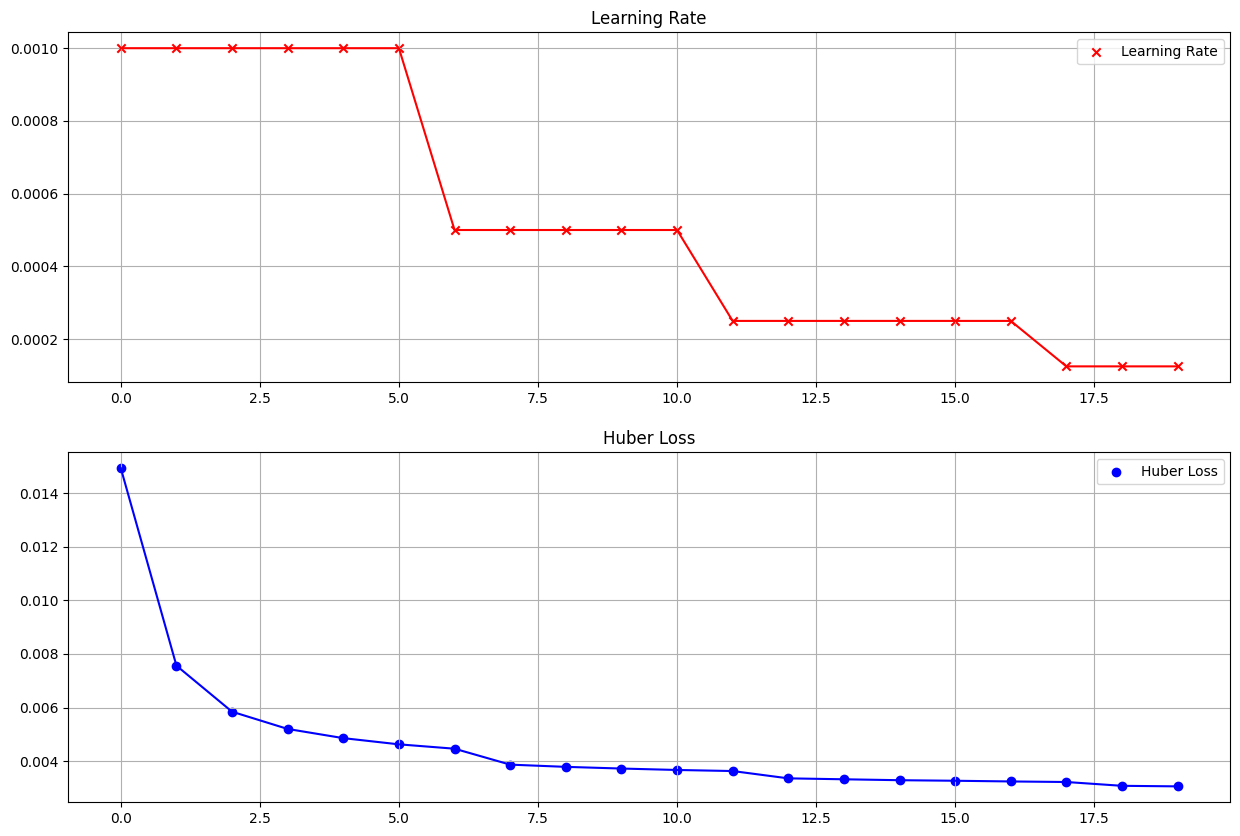

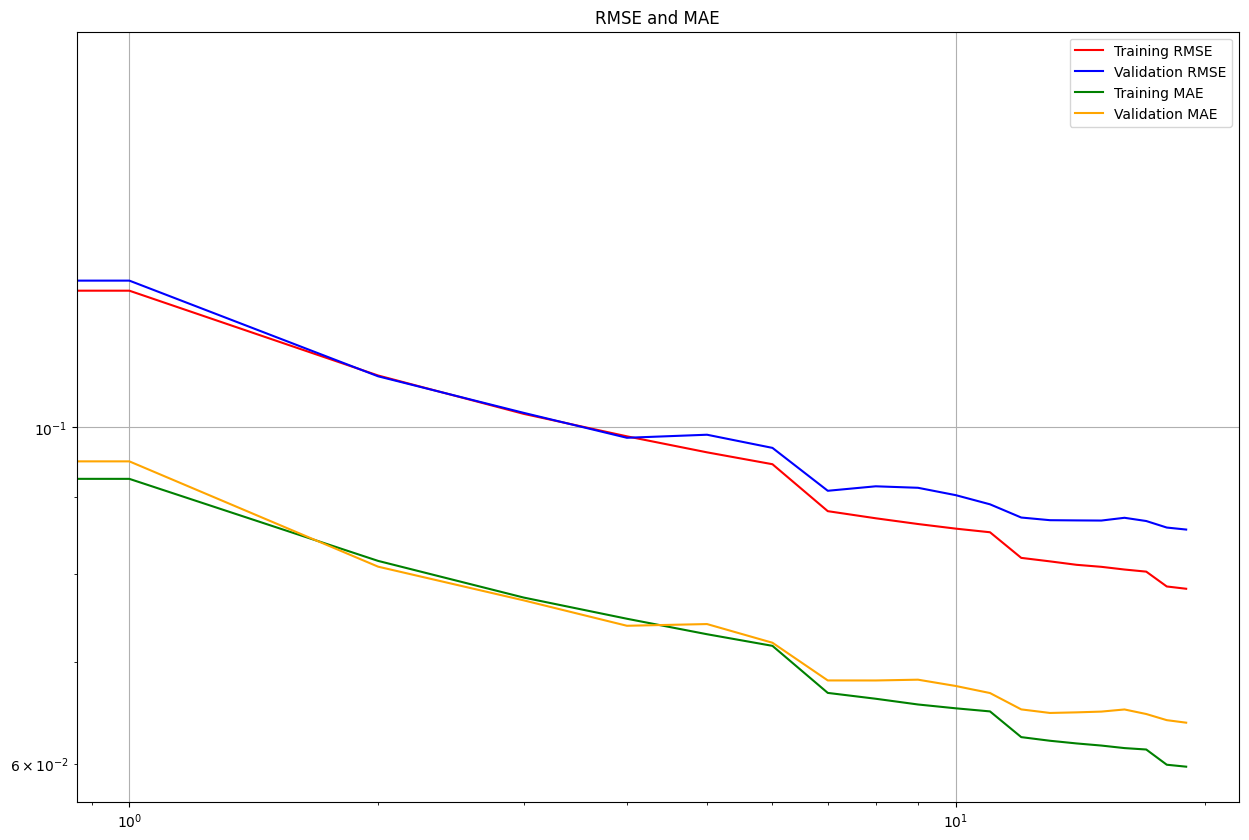

In [ ]:
fig, ax=plt.subplots(figsize=(15,10))
ax.axis('off')
Plot1=plt.subplot(2,1,1)
Plot2=plt.subplot(2,1,2)

Plot2.set_title('Huber Loss')
Plot2.scatter(losses,label='Huber Loss',c='b')
Plot2.plot(losses,c='b')
Plot2.legend(loc='best')
Plot2.grid('on')


Plot1.set_title('Learning Rate')
Plot1.scatter(learning_rate,label='Learning Rate',c='r')
Plot1.plot(learning_rate, c='r')
Plot1.legend(loc='best')
Plot1.grid('on')


fig, Model=plt.subplots(figsize=(15,10))
Model.set_title('RMSE and MAE')
Model.loglog(Train_RMSE, label='Training RMSE', c='r')
Model.loglog(Val_RMSE, label='Validation RMSE', c='b')

Model.loglog(Train_MAE, label='Training MAE', c='g')
Model.loglog(Val_MAE, label='Validation MAE', c='orange')
Model.grid('on')
Model.legend(loc='best')

# Random Forest

In [ ]:
Rf_RMSE = []
Rf_MAE = []
Rf_R2 = []


Rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=50,
    max_features="sqrt",
    n_jobs=2,
    random_state=41)
Rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=50,
                      n_estimators=200, n_jobs=2, random_state=41)

In [ ]:
Rf_pred=Rf.predict(X_val)

Rf_RMSE = np.sqrt(mean_squared_error(y_val, Rf_pred))
Rf_MAE = mean_absolute_error(y_val, Rf_pred)
Rf_R2 = r2_score(y_val, Rf_pred)

# XGBoost
---

In [ ]:
Gb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric=["rmse", "mae"])

In [ ]:
Gb.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False)

results = Gb.evals_result()
pred = Gb.predict(X_test)
Gb_R2= r2_score(y_test,pred)

# Risultati

In [ ]:
results = pd.DataFrame({
    "Model": ["DNN","Random Forest","XG Boost"],
    "R2":    [R2,         Rf_R2,          Gb_R2],
    "RMSE":  [RMSE,       Rf_RMSE,        min(results["validation_0"]["rmse"])],
    "MAE":   [MAE,        Rf_MAE,         min(results["validation_0"]["mae"])]
})

results

,Model,R2,RMSE,MAE
0,DNN,0.886234,0.007119,0.063744
1,Random Forest,0.756494,0.130768,0.098291
2,XG Boost,0.812792,0.111540,0.085322


In [ ]:
# results.to_latex(
#     "Confronto.tex",
#     index=False,          # non esporta l'indice
#     float_format="%.3f",  # formato numeri float
#     caption="Risultati",
#     label="tab:risultati"
# )